# Reconstructing a probability distribution

In [1]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

import QCut as ck
from QCut import cutGate

A cut experiment estimates expectation values, so there are no counts to tally. Passing `qubits` instead of `observables` reconstructs the distribution over those qubits.

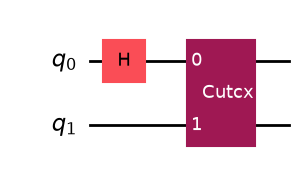

In [2]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.append(**cutGate(CXGate(), 0, 1))

circuit.decompose(gates_to_decompose=["CutGate"]).draw("mpl")

In [3]:
cut_circuit = ck.get_locations_and_subcircuits(circuit)
cut_experiment = ck.get_experiment_circuits(cut_circuit, qubits=[0, 1])

cut_experiment.observables

SparsePauliOp(['IZ', 'ZI', 'ZZ'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j])

In [4]:
results = ck.run_experiments(cut_experiment, shots=4096, backend=AerSimulator())

probs = ck.estimate_probabilities(results)
probs

{'00': np.float64(0.48764103651046753),
 '01': np.float64(-0.006806075572967529),
 '10': np.float64(0.006803929805755615),
 '11': np.float64(0.5123611092567444)}

The values are quasi-probabilities, so one can come out negative. `nearest_probabilities()` gives the closest true distribution and `counts()` scales it by the shots the experiment ran at.

In [5]:
probs.nearest_probabilities()

{'00': np.float64(0.4853723446528117),
 '01': 0.0,
 '10': np.float64(0.0045352379480997716),
 '11': np.float64(0.5100924173990885)}

In [6]:
probs.counts()

{'00': np.float64(1988.0851236979167),
 '01': 0.0,
 '10': np.float64(18.576334635416664),
 '11': np.float64(2089.3385416666665)}

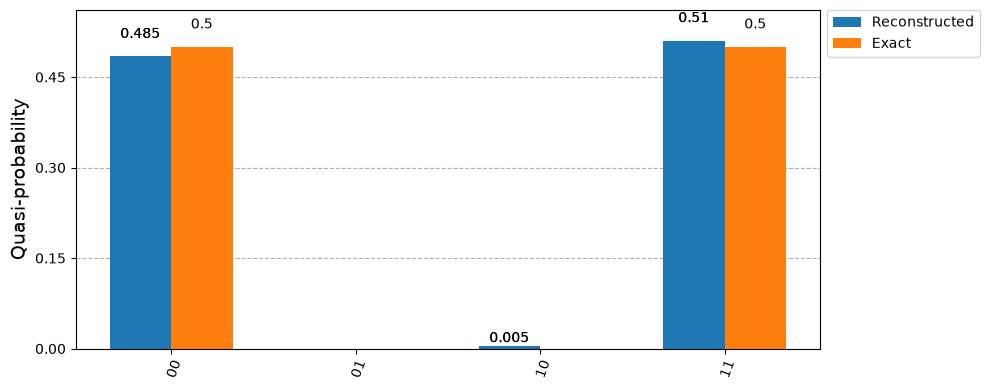

In [7]:
exact = Statevector(bell).probabilities_dict()

plot_histogram(
    [probs.nearest_probabilities(), exact],
    legend=["Reconstructed", "Exact"],
    figsize=(10, 4),
)

The observables grow as `2**k`, but the circuits do not. Every Z string commutes with the others, so they share one measurement setting.

In [8]:
wide = QuantumCircuit(6)
wide.h(0)
wide.append(**cutGate(CXGate(), 0, 1))
for qubit in range(1, 5):
    wide.cx(qubit, qubit + 1)

for width in (2, 4, 6):
    experiment = ck.get_experiment_circuits(
        ck.get_locations_and_subcircuits(wide), qubits=list(range(width))
    )
    print(
        f"{width} qubits: {len(experiment.observables):3d} observables, "
        f"{experiment.num_obs_groups} measurement setting, "
        f"{experiment.num_circuits} circuits"
    )

2 qubits:   3 observables, 1 measurement setting, 12 circuits
4 qubits:  15 observables, 1 measurement setting, 12 circuits
6 qubits:  63 observables, 1 measurement setting, 12 circuits
